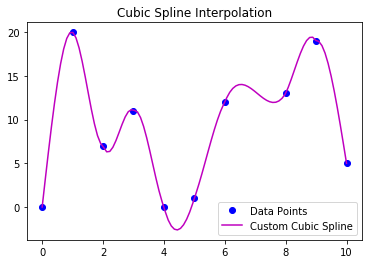

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def compute_h(x):# finds the x distance between points
    h = []
    for i in range(len(x) - 1):
        h.append(x[i+1] - x[i])
    return h



# Tridiagonal System code from the power point slides
def build_system(x, y):
    n = len(x)
    h = compute_h(x)

    A = [0] * (n-2)
    B = [0] * (n-2)
    C = [0] * (n-2)
    D = [0] * (n-2)

    for i in range(1, n-1):
        A[i-1] = h[i-1]
        B[i-1] = 2 * (h[i-1] + h[i])
        C[i-1] = h[i]
        D[i-1] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])

    return A, B, C, D



# Thomas Algorithm code from the power point slides
def thomas_algorithm(a, b, c, d):
    n = len(b)

    # Make a copy of the arrays
    a, b, c, d = map(np.array, (a, b, c, d))

    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]

    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]

    return x



# Computes the Second Derivative as that is what gives the curves
#Understood that the two function I made needed to be used, but
#needed chatGPT to explain how to implement them properly

def compute_E(x, y):
    n = len(x)

    A, B, C, D = build_system(x, y)

    E_internal = thomas_algorithm(A, B, C, D)

    E = np.zeros(n)
    E[1:n-1] = E_internal

    return E



# Takes the curvatures calculated to build the spline
def evaluate_spline(x, y, E, x_eval):
    n = len(x)
    y_eval = []

    for xe in x_eval: # GPT used to implement the nested for loops
        S = 0  
        found = False

        for i in range(n-1):
            if not found and x[i] <= xe <= x[i+1]:

                hi = x[i+1] - x[i]
                # cubic spline code from slides
                S = (
                    (E[i] / (6 * hi)) * (x[i+1] - xe)**3 +
                    (E[i+1] / (6 * hi)) * (xe - x[i])**3 +
                    (y[i] / hi - E[i] * hi / 6) * (x[i+1] - xe) +
                    (y[i+1] / hi - E[i+1] * hi / 6) * (xe - x[i])
                )

                found = True

        y_eval.append(S)

    return np.array(y_eval)



# data set
x = np.array([0,1,2,3,4,5,6,8,9,10])
y = np.array([0,20,7,11,0,1,12,13,19,5])

# run the compute second derivatives function
E = compute_E(x, y)

# gathers the smoothened x and y points 
x_interp = np.linspace(0,10,100)
y_spline = evaluate_spline(x, y, E, x_interp)


# plot
plt.plot(x, y, 'bo', label="Data Points")
plt.plot(x_interp, y_spline, 'm', label="Custom Cubic Spline")
plt.title("Cubic Spline Interpolation")
plt.legend()
plt.show()